# Car Dashboard Detection Notebook

## Installs and Imports

In [ ]:
!pip install roboflow
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install Ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 86.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
Looking in indexes: https://download.pytorch.org/whl/cu121
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.9 MB/s eta 0:00:00


In [ ]:
from roboflow import Roboflow
from ctypes import BigEndianStructure
from ultralytics import YOLO
from IPython.display import Image as IPyImage, display, HTML
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import glob
import os
from ipywidgets import HBox, Image as WImage
import base64
from collections import Counter
from collections import defaultdict
from PIL import Image
import yaml
import plotly.graph_objects as go
import cv2
from io import BytesIO
from tqdm import tqdm
import albumentations as A
import shutil
from ultralytics import settings

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Data Loading

In [ ]:
rf = Roboflow(api_key="YBaBoieNSNnA7fkaAghG")
project = rf.workspace("lpr-k8izp").project("enhanced-dashboard-ds")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Enhanced-Dashboard-DS-1 in yolov11:: 100%|██████████| 6380/6380 [00:02<00:00, 3162.34it/s]


In [ ]:
labels_dir = "/content/Enhanced-Dashboard-DS-1/train/labels"
data_yaml = "/content/Enhanced-Dashboard-DS-1/data.yaml"

with open(data_yaml) as f:
    data = yaml.safe_load(f)
names = data["names"]

counts = Counter()
for file in os.listdir(labels_dir):
    if not file.endswith(".txt"):
        continue
    with open(os.path.join(labels_dir, file)) as f:
        for line in f:
            if line.strip():
                cls_id_str = line.split()[0]
                cls_id = int(float(cls_id_str))
                counts[cls_id] += 1

for cls_id, count in sorted(counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{names[cls_id]:<20} : {count}")

brake                : 1704
check_engine         : 1566
seatbelt             : 1220
Battery              : 1122
oil_pressure         : 1053
tire_pressure        : 1020
Airbag               : 903
slip                 : 791
ABS                  : 744
Fuel                 : 666
engine_temperature   : 609
open_door            : 318
stability_control    : 252
park_lamb            : 225
ep_steering          : 195
security             : 192
eco                  : 108
low_beam             : 96
traction_control     : 96
maintenance          : 69
all_wheel            : 45
transmission         : 42
lamb_out             : 36
fog                  : 30
park_assist          : 27
beam                 : 24
hill_holder          : 24
low_speed            : 24
drivetrain           : 24
Electronic_Throttle  : 18
cruise               : 18
low_brake            : 15
glow_plug            : 15
headlamb_levelling   : 12
start_stop           : 12
washer               : 12
lane_departure       : 12
coolant        

## Preprocessing

In [ ]:
dataset_dir = "/content/Enhanced-Dashboard-DS-1"
name_variants = {
    "maintanence": "maintenance",
}

yaml_path = os.path.join(dataset_dir, "data.yaml")

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)
names = data.get("names", [])

for old, new in name_variants.items():
    if old in names:
        print(f"[INFO] Merging '{old}' -> '{new}'")
        old_idx = names.index(old)
        if new not in names:
            names[old_idx] = new
            continue
        new_idx = names.index(new)
        for split in ["train", "valid", "test"]:
            labels_dir = os.path.join(dataset_dir, split, "labels")
            if not os.path.exists(labels_dir):
                continue
            for file in os.listdir(labels_dir):
                if not file.endswith(".txt"):
                    continue
                path = os.path.join(labels_dir, file)
                with open(path, "r") as f:
                    lines = f.readlines()
                new_lines = []
                for line in lines:
                    parts = line.strip().split()
                    if not parts:
                        continue
                    cid = int(float(parts[0]))
                    if cid == old_idx:
                        cid = new_idx
                    elif cid > old_idx:
                        cid -= 1
                    new_lines.append(" ".join([str(cid)] + parts[1:]))
                with open(path, "w") as f:
                    f.write("\n".join(new_lines))
        names.pop(old_idx)
        print(f"[INFO] Removed duplicate '{old}' (merged into '{new}')")

data["names"] = names
data["nc"] = len(names)
with open(yaml_path, "w") as f:
    yaml.safe_dump(data, f)

invalid_count = 0
for split in ["train", "valid", "test"]:
    labels_dir = os.path.join(dataset_dir, split, "labels")
    if not os.path.exists(labels_dir):
        continue
    for file in os.listdir(labels_dir):
        if not file.endswith(".txt"):
            continue
        path = os.path.join(labels_dir, file)
        with open(path, "r") as f:
            lines = f.readlines()
        valid = True
        for line in lines:
            parts = line.strip().split()
            if not parts:
                continue
            cid = int(float(parts[0]))
            if cid >= len(names):
                valid = False
                break
        if not valid:
            invalid_count += 1
            os.remove(path)

train_used = set()
train_labels = os.path.join(dataset_dir, "train", "labels")
for file in os.listdir(train_labels):
    if not file.endswith(".txt"):
        continue
    with open(os.path.join(train_labels, file), "r") as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                train_used.add(int(float(parts[0])))

unused_classes = [i for i in range(len(names)) if i not in train_used]
if unused_classes:
    print(f"[INFO] Removing {len(unused_classes)} unused classes not in train...")
    new_id_map = {}
    new_names = []
    new_idx = 0
    for i, name in enumerate(names):
        if i not in unused_classes:
            new_id_map[i] = new_idx
            new_names.append(name)
            new_idx += 1
    for split in ["train", "valid", "test"]:
        labels_dir = os.path.join(dataset_dir, split, "labels")
        if not os.path.exists(labels_dir):
            continue
        for file in os.listdir(labels_dir):
            if not file.endswith(".txt"):
                continue
            path = os.path.join(labels_dir, file)
            with open(path, "r") as f:
                lines = f.readlines()
            new_lines = []
            keep = True
            for line in lines:
                parts = line.strip().split()
                if not parts:
                    continue
                cid = int(float(parts[0]))
                if cid in unused_classes:
                    keep = False
                    break
                cid = new_id_map[cid]
                new_lines.append(" ".join([str(cid)] + parts[1:]))
            if keep:
                with open(path, "w") as f:
                    f.write("\n".join(new_lines))
            else:
                os.remove(path)
    names = new_names
    data["names"] = names
    data["nc"] = len(names)
    with open(yaml_path, "w") as f:
        yaml.safe_dump(data, f)

print(f"[DONE] Unified and merged all variants into one class.")
print(f"[INFO] Final class count: {len(names)}")
print(f"[CHECK] Removed {invalid_count} invalid label files with IDs >= nc.")

[INFO] Merging 'maintanence' -> 'maintenance'
[INFO] Removed duplicate 'maintanence' (merged into 'maintenance')
[INFO] Removing 1 unused classes not in train...
[DONE] Unified and merged all variants into one class.
[INFO] Final class count: 50
[CHECK] Removed 0 invalid label files with IDs >= nc.


In [ ]:
base_dir = "/content/Enhanced-Dashboard-DS-1"

images_dir = f"{base_dir}/train/images"
labels_dir = f"{base_dir}/train/labels"

aug_img_dir = f"{base_dir}/train_aug/images"
aug_lbl_dir = f"{base_dir}/train_aug/labels"

data_yaml = f"{base_dir}/data.yaml"

os.makedirs(aug_img_dir, exist_ok=True)
os.makedirs(aug_lbl_dir, exist_ok=True)

augment = A.Compose(
    [
        A.RandomBrightnessContrast(0.15, 0.25, p=0.6),
        A.Affine(
            translate_percent=0.03,
            scale=(0.85, 1.15),
            rotate=(-5, 5),
            p=0.3
        ),
        A.Sharpen(alpha=(0.2, 0.4), lightness=(0.7, 1.0), p=0.3),
    ],
    bbox_params=A.BboxParams(
        format="yolo",
        min_visibility=0.2,
        label_fields=["class_labels"]
    )
)

with open(data_yaml, "r") as f:
    data = yaml.safe_load(f)

names = data["names"]
id_to_class = {i: n for i, n in enumerate(names)}
counts = defaultdict(int)

for lf in os.listdir(labels_dir):
    if lf.endswith(".txt"):
        with open(os.path.join(labels_dir, lf)) as f:
            for line in f:
                if line.strip():
                    counts[names[int(float(line.split()[0]))]] += 1

def get_n_aug(count):
    if count < 5: return 30
    if count < 10: return 20
    if count < 50: return 10
    if count < 100: return 5
    if count < 200: return 3
    return 0

def find_image(label_file):
    base = os.path.splitext(label_file)[0]
    for ext in [".jpg", ".png", ".jpeg", ".JPG"]:
        p = os.path.join(images_dir, base + ext)
        if os.path.exists(p):
            return p
    return None

generated = defaultdict(int)

for label_file in tqdm(os.listdir(labels_dir), desc="Augmenting"):
    if not label_file.endswith(".txt"):
        continue

    img_path = find_image(label_file)
    if img_path is None:
        continue

    with open(os.path.join(labels_dir, label_file)) as f:
        lines = f.readlines()

    if not lines:
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue

    bboxes, class_labels = [], []
    for line in lines:
        cls, x, y, w, h = map(float, line.split())
        bboxes.append([x, y, w, h])
        class_labels.append(int(cls))

    n_aug = max(get_n_aug(counts[id_to_class[c]]) for c in set(class_labels))
    if n_aug == 0:
        continue

    for i in range(n_aug):
        aug = augment(image=img, bboxes=bboxes, class_labels=class_labels)
        if len(aug["bboxes"]) == 0:
            continue

        img_name = f"aug_{i}_{os.path.basename(img_path)}"
        lbl_name = f"aug_{i}_{label_file}"

        cv2.imwrite(os.path.join(aug_img_dir, img_name), aug["image"])

        with open(os.path.join(aug_lbl_dir, lbl_name), "w") as out:
            for cls, (x, y, w, h) in zip(aug["class_labels"], aug["bboxes"]):
                out.write(f"{cls} {x} {y} {w} {h}\n")
                generated[id_to_class[cls]] += 1

for f in os.listdir(aug_img_dir):
    shutil.move(os.path.join(aug_img_dir, f), os.path.join(images_dir, f))

for f in os.listdir(aug_lbl_dir):
    shutil.move(os.path.join(aug_lbl_dir, f), os.path.join(labels_dir, f))

shutil.rmtree(f"{base_dir}/train_aug")

print("\n[REPORT] Augmentation Summary")
for cls in sorted(generated):
    print(f"{cls:<20}: {generated[cls]} new objects")

print(f"\nTotal augmented objects: {sum(generated.values())}")
print("✔ train_aug merged into train and removed successfully")

Augmenting: 100%|██████████| 2964/2964 [00:21<00:00, 137.08it/s]



[REPORT] Augmentation Summary
ABS                 : 1762 new objects
Airbag              : 2387 new objects
Battery             : 2884 new objects
Electronic_Throttle : 180 new objects
Fuel                : 1472 new objects
all_wheel           : 450 new objects
auto                : 90 new objects
awd                 : 120 new objects
beam                : 360 new objects
brake               : 3681 new objects
brake_Assist        : 90 new objects
check_engine        : 3675 new objects
coolant             : 210 new objects
cruise              : 180 new objects
drivetrain          : 270 new objects
eco                 : 750 new objects
eco2                : 120 new objects
engine_temperature  : 1314 new objects
ep_steering         : 1096 new objects
ev                  : 120 new objects
fan                 : 210 new objects
fog                 : 300 new objects
glow_plug           : 210 new objects
headlamb_levelling  : 120 new objects
hill_holder         : 240 new objects
hold         

## Model Training

In [ ]:
model = YOLO("yolo11n.pt")
train_results = model.train(
    data=data_yaml,
    epochs=100,
    imgsz=960,
    batch=-1,
    patience=10,
    lr0=0.001,
    optimizer="auto",
    fliplr=0.0,
    mosaic=0.2,
    mixup=0.0,
    hsv_s=0.4,
    translate=0.0,
    cos_lr=True,
    hsv_v=0.0,
    auto_augment=None,
)

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=None, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/Enhanced-Dashboard-DS-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.0, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.2, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True,

## Evaluation and Results

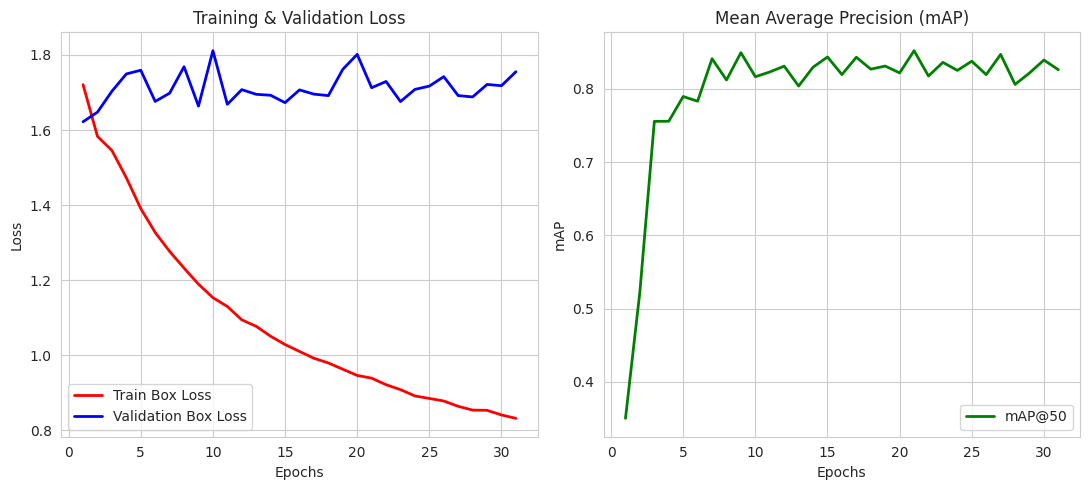

In [ ]:
df = pd.read_csv('/content/runs/detect/train/results.csv')

map_column = "metrics/mAP50(B)"
loss_column_train = "train/box_loss"
loss_column_val = "val/box_loss"

plt.figure(figsize=(11,5))

sns.set_style("whitegrid");

plt.subplot(1, 2, 1)
plt.plot(df["epoch"], df[loss_column_train], label="Train Box Loss", color="red", linewidth=2)
plt.plot(df["epoch"], df[loss_column_val], label="Validation Box Loss", color="blue", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df["epoch"], df[map_column], label="mAP@50", color="green", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("mAP")
plt.title("Mean Average Precision (mAP)")
plt.legend()

plt.tight_layout()

plt.show()

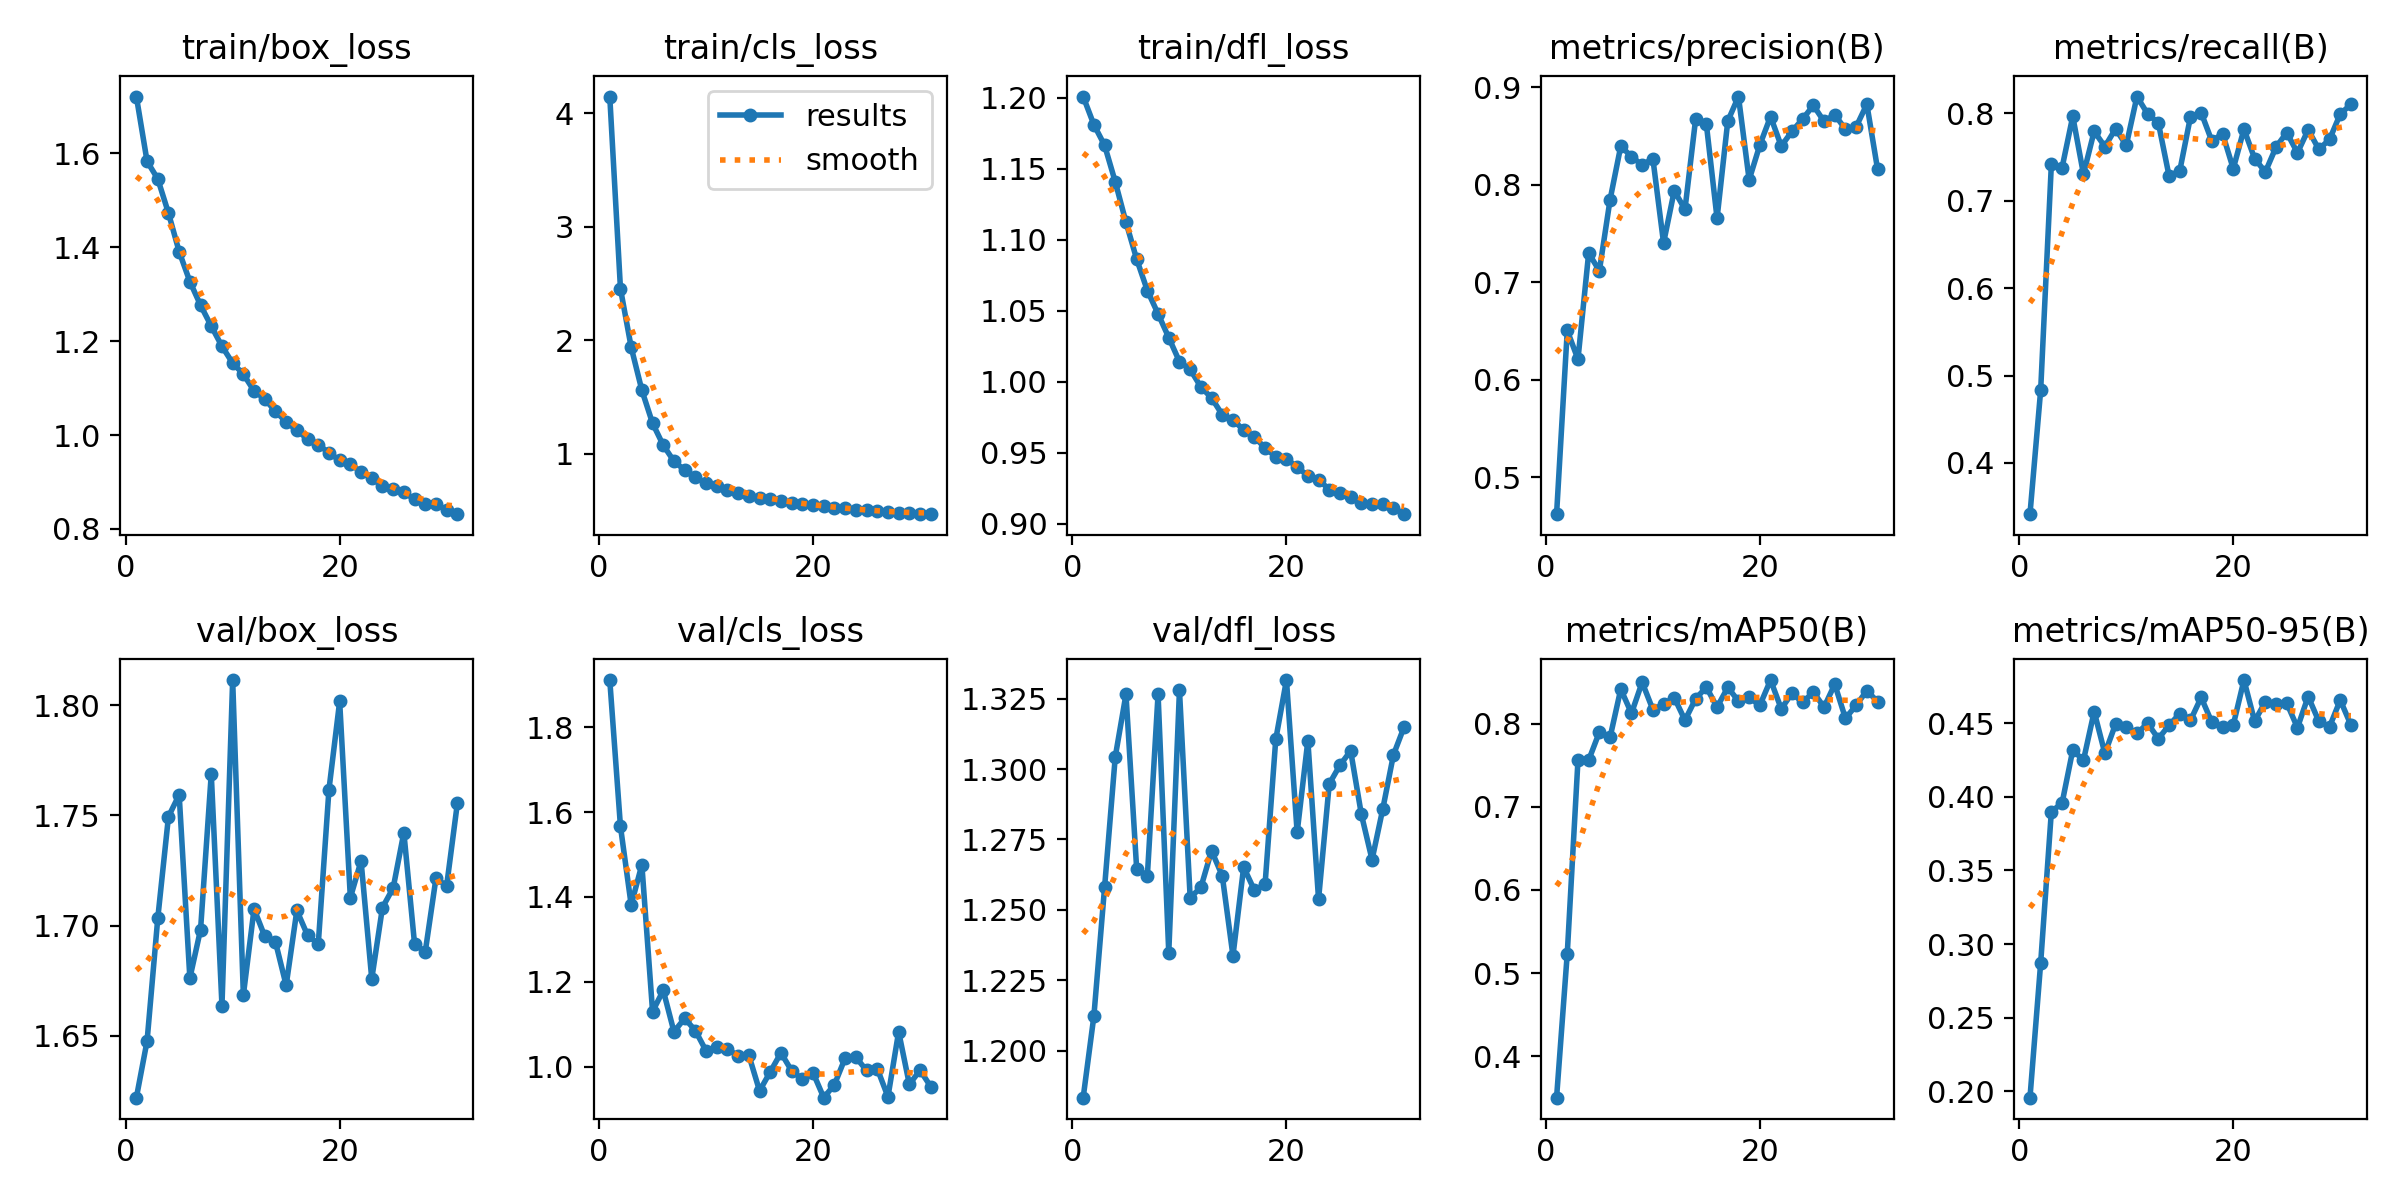

In [ ]:
IPyImage(filename=f'/content/runs/detect/train/results.png', width=900)

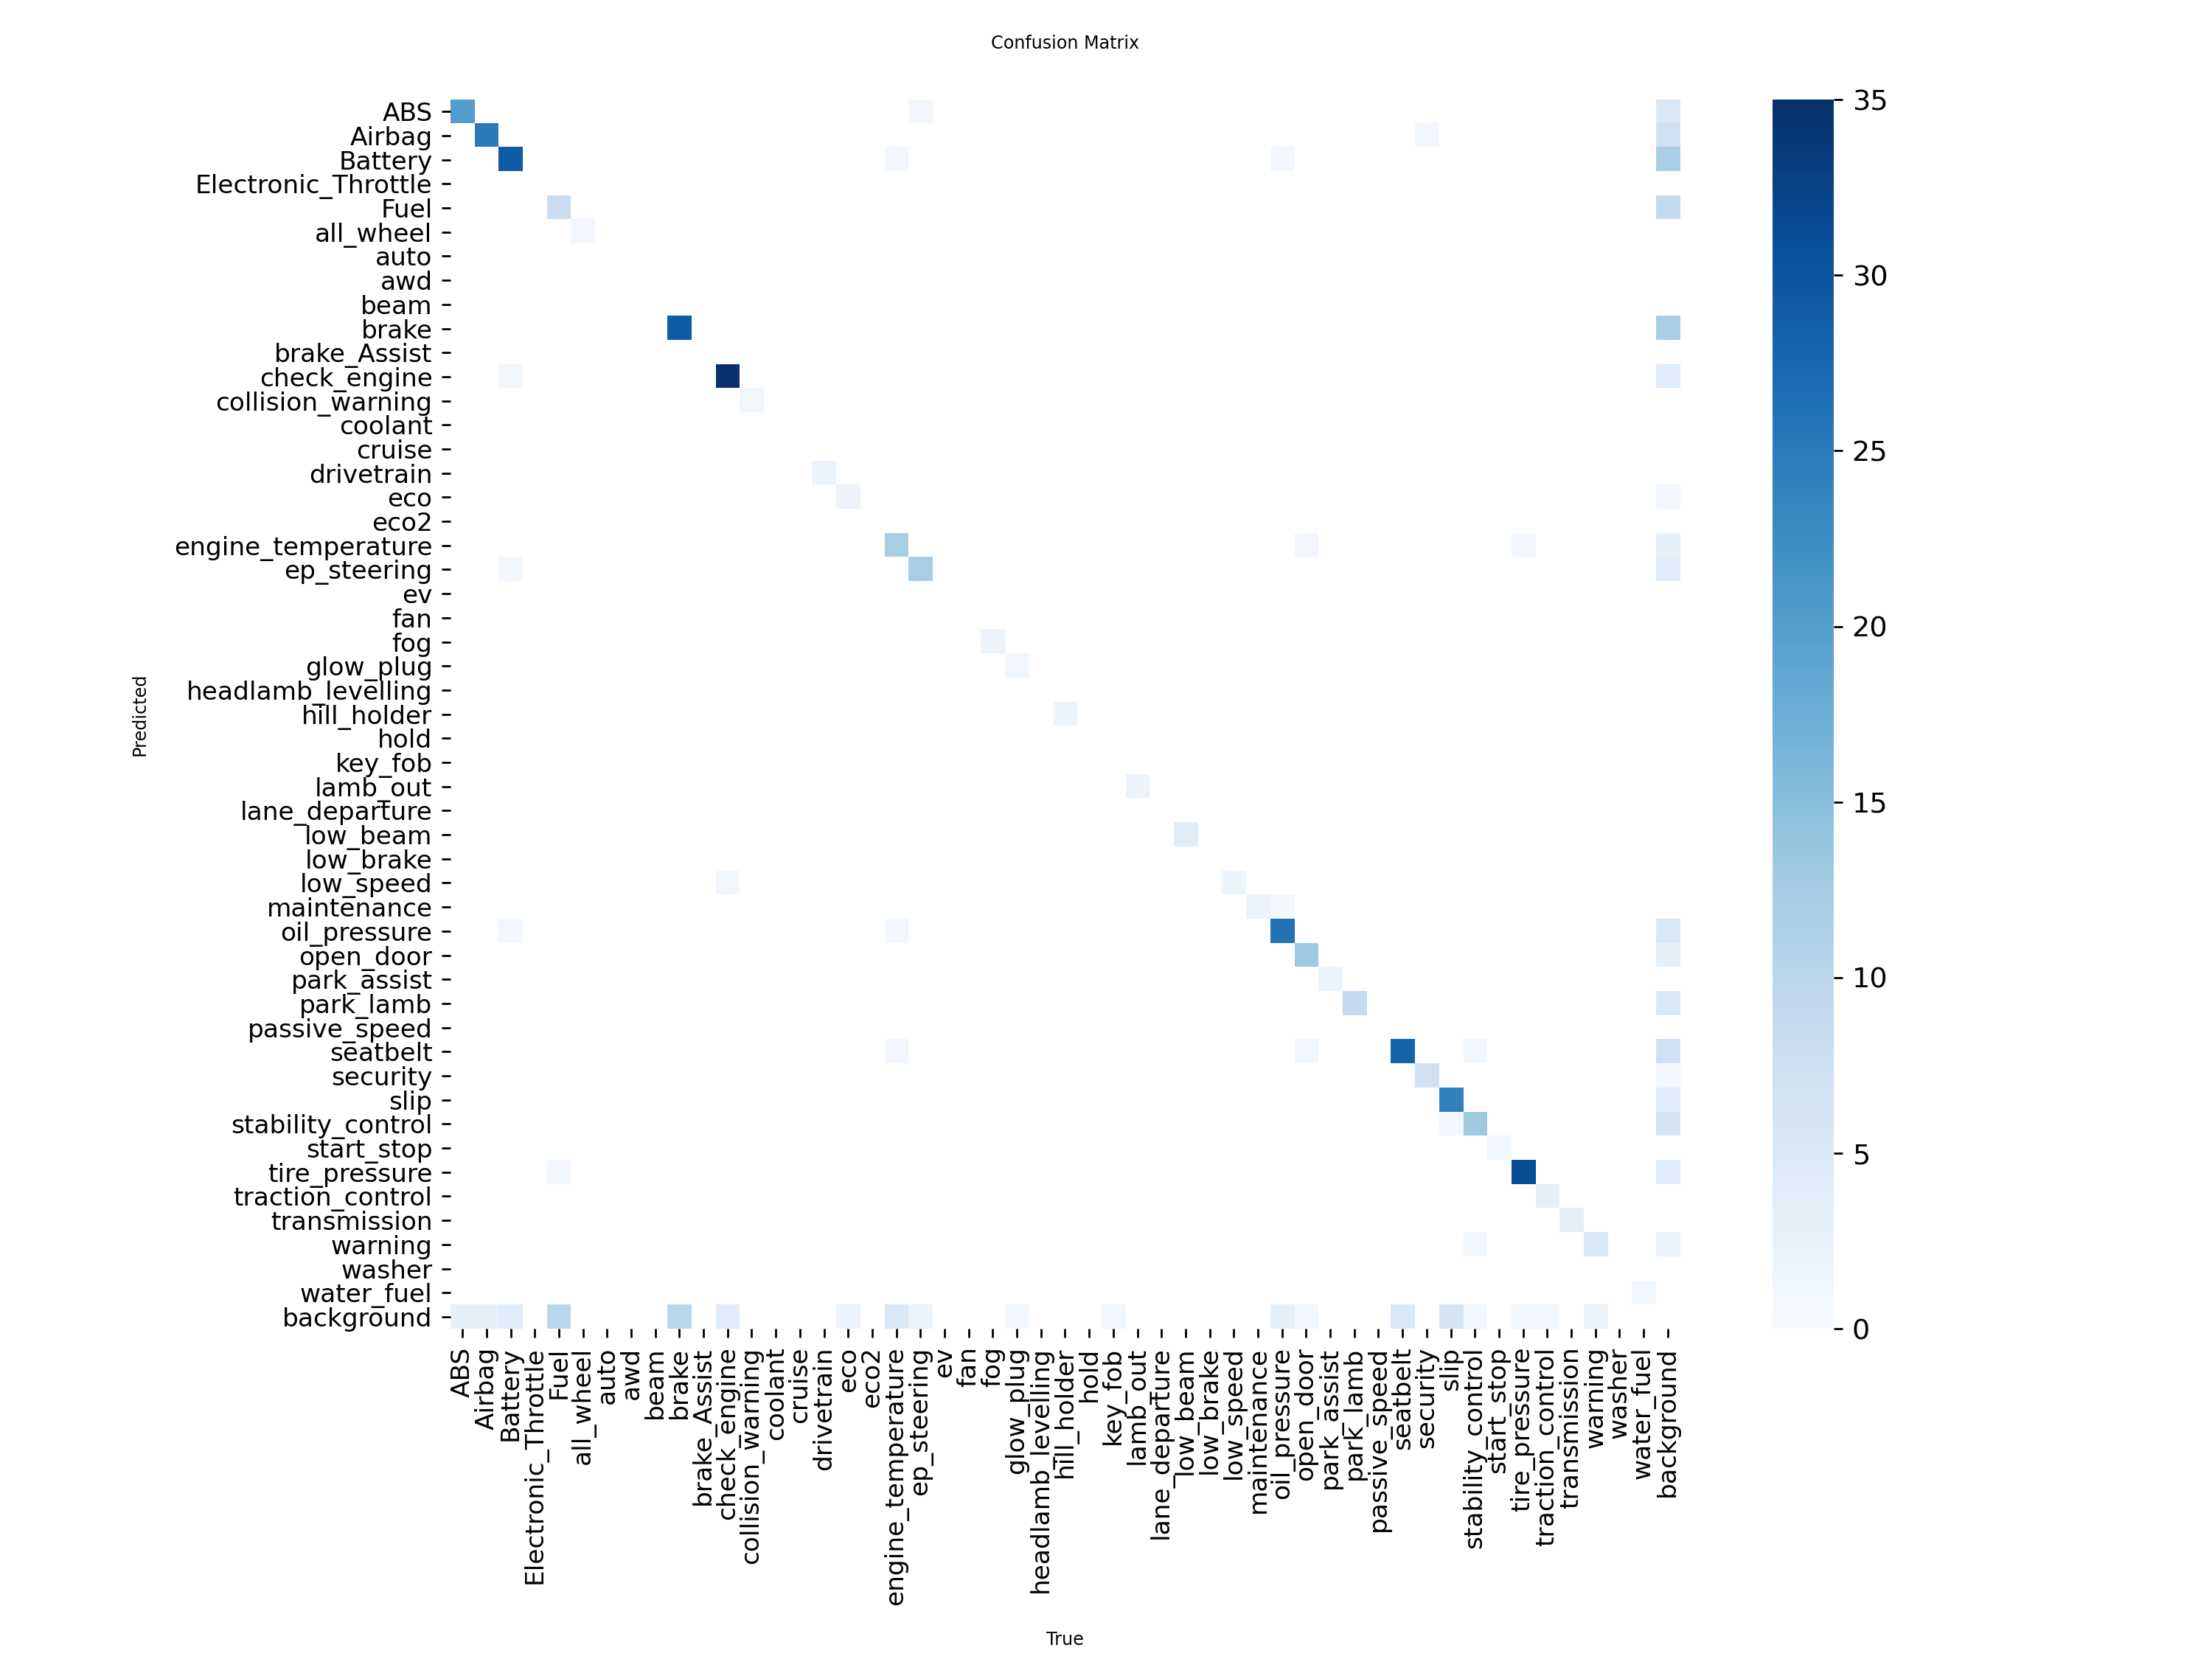

In [ ]:
IPyImage(filename=f'/content/runs/detect/train/confusion_matrix.png', width=900)

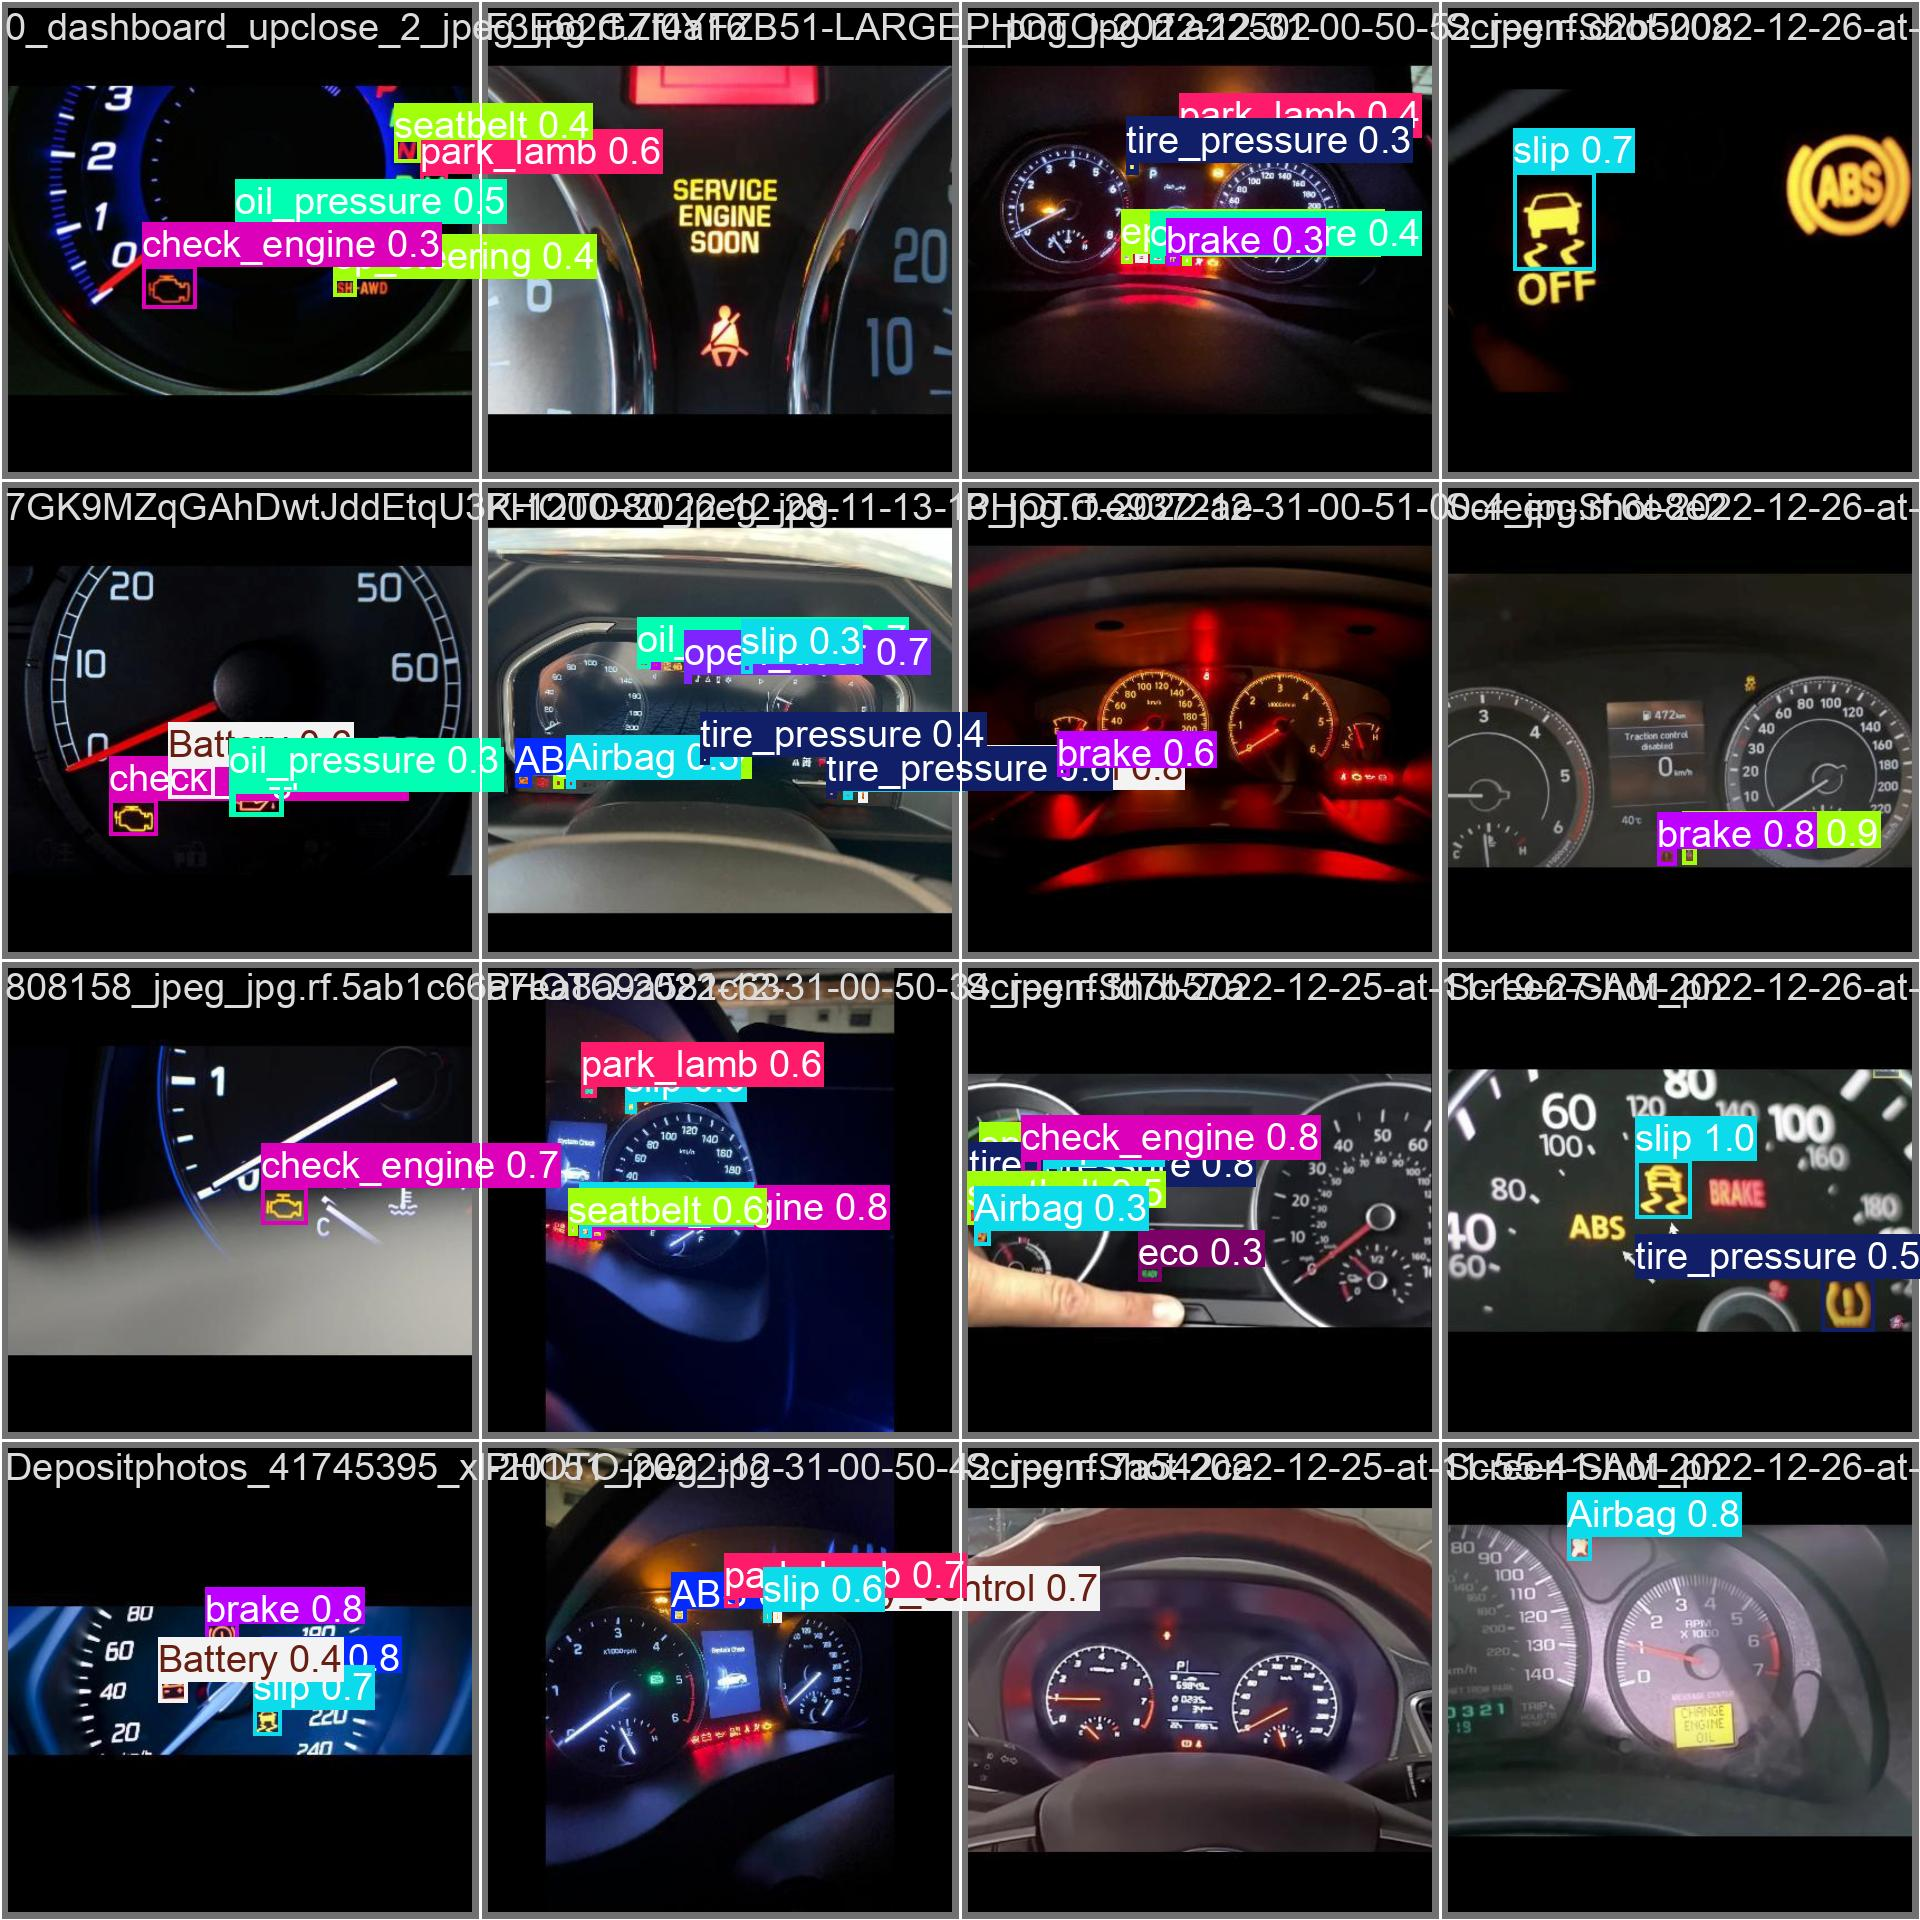

In [ ]:
IPyImage(filename=f'/content/runs/detect/train/val_batch0_pred.jpg', width=1200)

In [ ]:
model.val(data=data_yaml, split="test", verbose=True)

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,591,902 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 15.2±7.8 MB/s, size: 16.4 KB)
val: Scanning /content/Enhanced-Dashboard-DS-1/test/labels... 128 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 129/129 1.1Kit/s 0.1s
val: New cache created: /content/Enhanced-Dashboard-DS-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.0it/s 4.5s
                   all        129        835      0.851      0.626      0.701      0.372
                   ABS         46         46      0.869      0.674      0.786      0.441
                Airbag         51         51      0.927      0.863       0.97      0.474
               Battery         71         71      0.825       0.73      0.807      0.438
                  Fuel         31         33      0.667   

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  4,  5,  9, 10, 11, 12, 14, 16, 17, 18, 19, 22, 23, 25, 26, 27, 28, 30, 31, 32, 33, 34, 35, 36, 37, 39, 40, 41, 42, 44, 45, 46, 47, 49])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f3c11338c80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.

In [ ]:
results = model.predict(
    source=f"/content/Enhanced-Dashboard-DS-1/test/images",
    conf=0.5,
    save=True,
    imgsz=960,
    rect=True,
    project="runs/detect",
    name="test"
)


image 1/129 /content/Enhanced-Dashboard-DS-1/test/images/16_Dash_Warning_Lights_jpeg_jpg.rf.91599bd63a2d5540b6a80e2be5ea175b.jpg: 960x960 1 Airbag, 2 Fuels, 1 brake, 39.6ms
image 2/129 /content/Enhanced-Dashboard-DS-1/test/images/CAA-Niagara_Dashboard-blog_jpeg_jpg.rf.3fc426778b997580b29b28937b643dc2.jpg: 960x960 1 Battery, 1 brake, 1 check_engine, 1 oil_pressure, 1 seatbelt, 1 security, 55.4ms
image 3/129 /content/Enhanced-Dashboard-DS-1/test/images/PHOTO-2022-12-28-11-48-20_jpg.rf.51cfd5bb631cb28a20e62aeb32cef681.jpg: 960x960 1 seatbelt, 1 tire_pressure, 30.3ms
image 4/129 /content/Enhanced-Dashboard-DS-1/test/images/PHOTO-2022-12-28-15-54-13_jpg.rf.8e664eb10011ab4364b783a32e31af1f.jpg: 960x960 1 Airbag, 1 Battery, 1 brake, 1 check_engine, 1 seatbelt, 19.8ms
image 5/129 /content/Enhanced-Dashboard-DS-1/test/images/PHOTO-2022-12-28-15-54-15-2_jpg.rf.858d1b8fdd3afe2a5e44b9e2bf7c982a.jpg: 960x960 1 Airbag, 2 Batterys, 1 check_engine, 1 seatbelt, 14.6ms
image 6/129 /content/Enhanced-Das

,,,,
,,,,
,,,,
,,,,

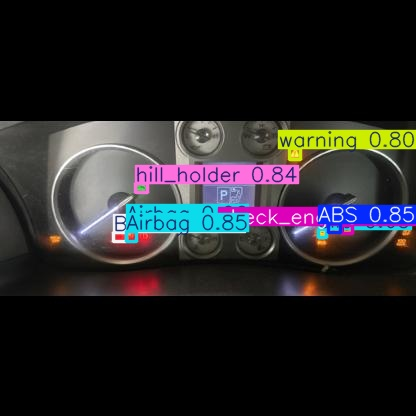
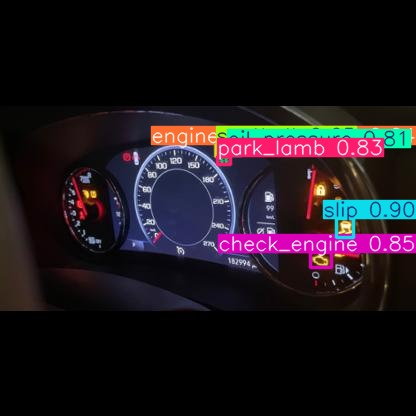
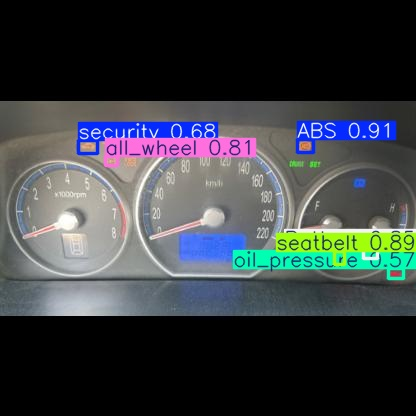
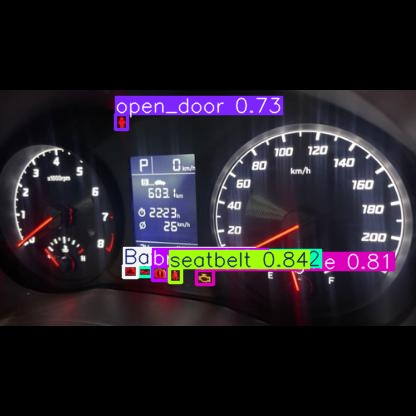
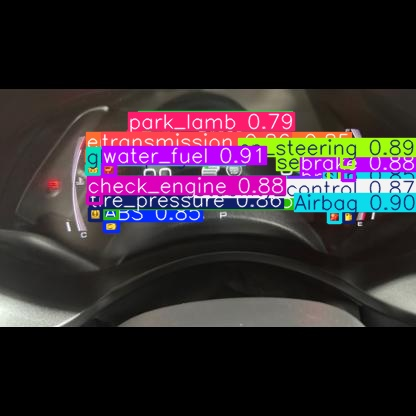
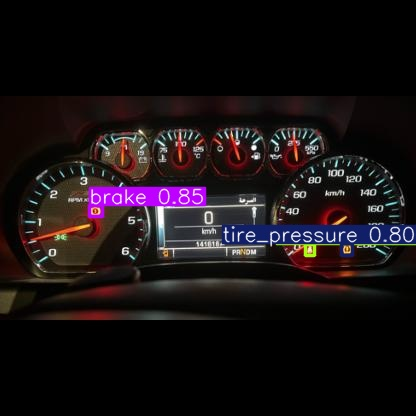
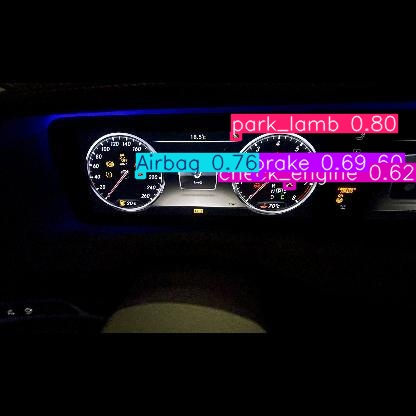
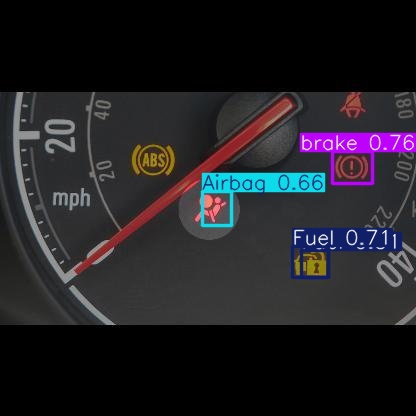
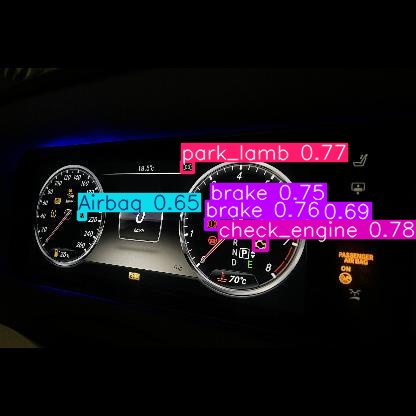
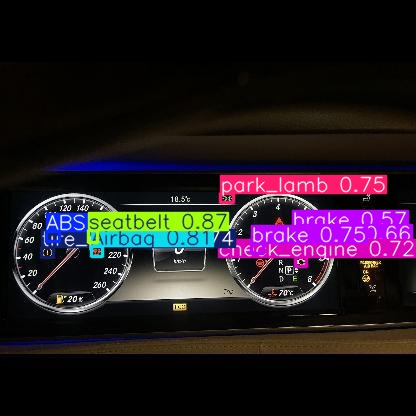
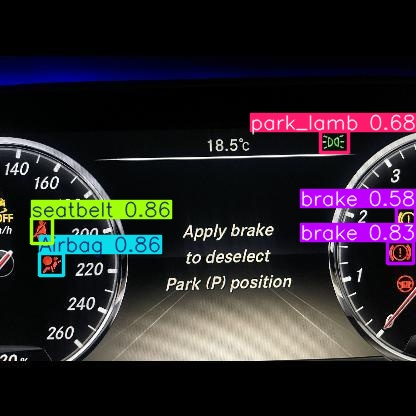
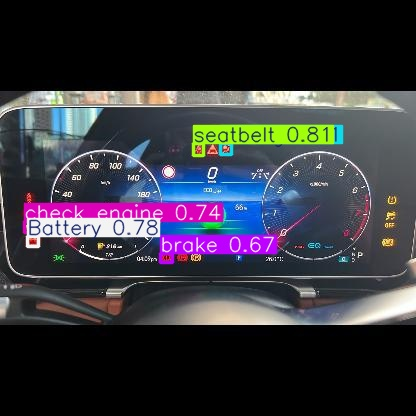
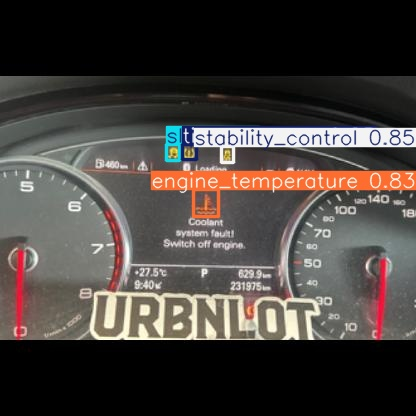
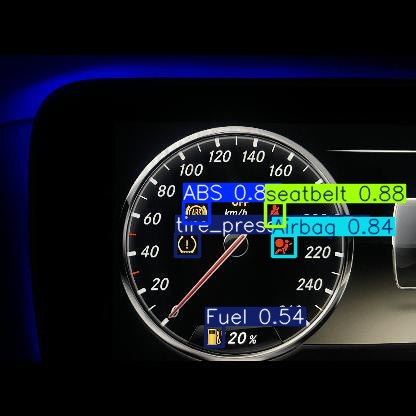
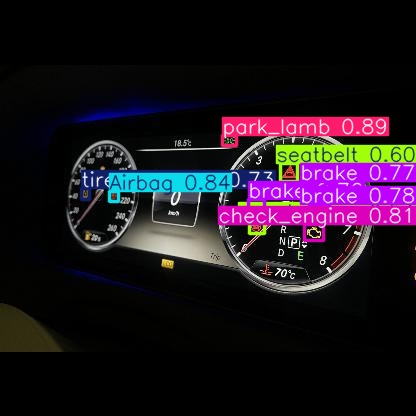
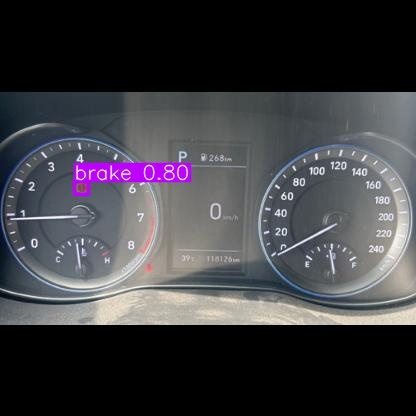
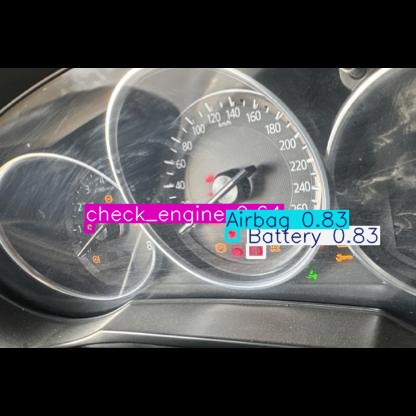
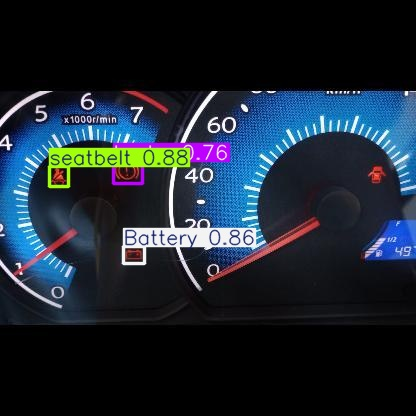
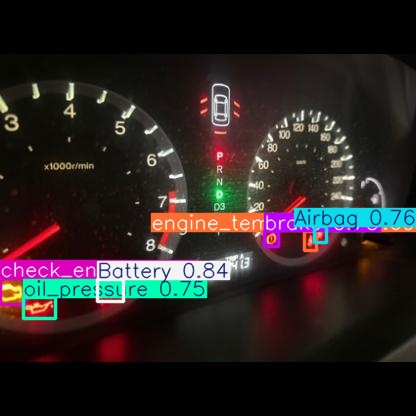
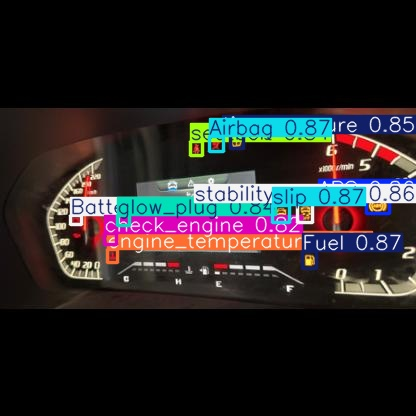

In [ ]:
def img_to_base64(img_path):
    with open(img_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
        return f'<img src="data:image/jpg;base64,{b64}" width="200"/>'

latest_folder = max(glob.glob('/content/runs/detect/test/'), key=os.path.getmtime)
images = glob.glob(f'{latest_folder}/*.jpg')[:20]

imgs_per_row = 5
html = "<table>"
for i in range(0, len(images), imgs_per_row):
    html += "<tr>"
    for img_path in images[i:i+imgs_per_row]:
        html += f"<td>{img_to_base64(img_path)}</td>"
    html += "</tr>"
html += "</table>"

display(HTML(html))

## Inference

In [ ]:
model = YOLO("/content/runs/detect/train/weights/best.pt")
results = model.predict("/content/1400x600-car-dashboard-lights-gettyimages-519216518.jpeg", conf=0.3, imgsz=960, save=False, rect=True)
r = results[0]

img = cv2.cvtColor(r.orig_img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

pil_img = Image.fromarray(img)
buffered = BytesIO()
pil_img.save(buffered, format="JPEG")
img_base64 = base64.b64encode(buffered.getvalue()).decode()
img_uri = f"data:image/jpeg;base64,{img_base64}"

fig = go.Figure()
fig.add_layout_image(
    dict(
        source=img_uri,
        xref="x",
        yref="y",
        x=0,
        y=h,
        sizex=w,
        sizey=h,
        sizing="stretch",
        layer="below"
    )
)

for box in r.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cls = int(box.cls)
    conf = float(box.conf)
    label = f"{model.names[cls]} ({conf:.2f})"

    fig.add_shape(
        type="rect",
        x0=x1,
        y0=h-y1,
        x1=x2,
        y1=h-y2,
        line=dict(color="magenta", width=2)
    )

    fig.add_trace(go.Scatter(
        x=[(x1 + x2) / 2],
        y=[h - (y1 + y2) / 2],
        text=[label],
        mode="markers",
        marker=dict(opacity=0),
        hovertemplate="%{text}<extra></extra>"
    ))

scale = 0.5
fig.update_xaxes(showticklabels=False, range=[0, w])
fig.update_yaxes(showticklabels=False, range=[0, h])
fig.update_layout(width=w * scale, height=h * scale, margin=dict(l=0, r=0, t=0, b=0))
fig.show()


image 1/1 /content/1400x600-car-dashboard-lights-gettyimages-519216518.jpeg: 416x960 1 Battery, 1 brake, 1 check_engine, 1 oil_pressure, 1 open_door, 1 seatbelt, 17.3ms
Speed: 4.7ms preprocess, 17.3ms inference, 1.8ms postprocess per image at shape (1, 3, 416, 960)
